In [1]:
########################################################################################################################
# BASED ON BLOG: Implementing neural machine translation using Keras
# https://towardsdatascience.com/implementing-neural-machine-translation-using-keras-8312e4844eb8
# DATA SOURCE: Tab-delimited Bilingual Sentence Pairs
# http://www.manythings.org/anki/
########################################################################################################################

import pandas as pd
import numpy as np
import string
from string import digits
import matplotlib.pyplot as plt
import re
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import tensorflow as tf
import requests
import zipfile
import os
import math
from google.colab import drive

print("Tensorflow version: " + tf.__version__)
print("Keras version: " + tf.keras.__version__)

Tensorflow version: 2.20.0
Keras version: 3.13.2


In [2]:
########################################################################################################################
# MOUNTING GOOGLE DRIVE
########################################################################################################################

drive.mount('/content/drive')

# Putanja na Google Drive-u gde će se čuvati rezultati
drive_results_folder = '/content/drive/MyDrive/TextTranslation_Results_Keras'
if not os.path.exists(drive_results_folder):
    os.makedirs(drive_results_folder)
    print(f"Napravljen direktorijum za rezultate na Drive-u: {drive_results_folder}")

Mounted at /content/drive


In [3]:
########################################################################################################################
# PARAMETERS
########################################################################################################################

# DATASET
language = 'srp'

# MODEL
latent_dim = 256

# TRAINING
init_lr = 1e-3
batch_size = 128
epochs = 1000
model_weights_path = os.path.join(drive_results_folder, f'nmt_{language}.weights.h5')

In [4]:
########################################################################################################################
# DOWNLOAD DATASET
########################################################################################################################

# Download and unpack into project root
data_url = f"https://www.manythings.org/anki/{language}-eng.zip"
zip_path = f"{language}-eng.zip"
data_path = f"{language}.txt"

if not os.path.exists(zip_path):
    print("Downloading dataset...")
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    response = requests.get(data_url, headers=headers)

    with open(zip_path, 'wb') as f:
        f.write(response.content)
    print("Finished.")

if not os.path.exists(data_path):
    print("Unpacking dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('./')

Finished.
Unpacking dataset...


In [5]:
########################################################################################################################
# LOAD AND PREPROCESS DATA
########################################################################################################################

# Load data
lines = pd.read_table(data_path, names=['source', 'target', 'comments'])

# Print sample data from lines
print(lines[['source', 'target']].sample(6))

########################################################################################################################
# PREPROCESS DATA

# Convert source and target text to lowercase
lines.source = lines.source.apply(lambda x: x.lower())
lines.target = lines.target.apply(lambda x: x.lower())

# Remove quotes from source and target text
lines.source = lines.source.apply(lambda x: re.sub("'", '', x))
lines.target = lines.target.apply(lambda x: re.sub("'", '', x))

# Convert cyrillic letters to latin
letter_map = {
    'а': 'a', 'б': 'b', 'в': 'v', 'г': 'g', 'д': 'd', 'ђ': 'đ',
    'е': 'e', 'ж': 'ž', 'з': 'z', 'и': 'i', 'ј': 'j', 'к': 'k',
    'л': 'l', 'љ': 'lj', 'м': 'm', 'н': 'n', 'њ': 'nj', 'о': 'o',
    'п': 'p', 'р': 'r', 'с': 's', 'т': 't', 'ћ': 'ć', 'у': 'u',
    'ф': 'f', 'х': 'h', 'ц': 'c', 'ч': 'č', 'џ': 'dž', 'ш': 'š'
}
trans_table = str.maketrans(letter_map)
lines.target = lines.target.apply(lambda x: x.translate(trans_table))

# create a set of all special characters
special_characters = set(string.punctuation)

# Remove all the special characters
lines.source = lines.source.apply(lambda x: ''.join(char1 for char1 in x if char1 not in special_characters))
lines.target = lines.target.apply(lambda x: ''.join(char1 for char1 in x if char1 not in special_characters))

# Remove digits from source and target sentences
num_digits = str.maketrans('','', digits)
lines.source = lines.source.apply(lambda x: x.translate(num_digits))
lines.target = lines.target.apply(lambda x: x.translate(num_digits))

# Remove extra spaces
lines.source = lines.source.apply(lambda x: x.strip())
lines.target = lines.target.apply(lambda x: x.strip())
lines.source = lines.source.apply(lambda x: re.sub(" +", " ", x))
lines.target = lines.target.apply(lambda x: re.sub(" +", " ", x))

# Add start and end tokens to target sequences
lines.target = lines.target.apply(lambda x: 'START_ ' + x + ' _END')
print(lines[['source', 'target']].sample(6))

########################################################################################################################
# Find all the source and target words and sort them

# Vocabulary of source language
all_source_words = set()
for source in lines.source:
    for word in source.split():
        if word not in all_source_words:
            all_source_words.add(word)

# Vocabulary of target
all_target_words = set()
for target in lines.target:
    for word in target.split():
        if word not in all_target_words:
            all_target_words.add(word)

# sort all unique source and target words
source_words = sorted(list(all_source_words))
target_words = sorted(list(all_target_words))

print('source_words', len(source_words), source_words[:15])
print('target_words', len(target_words), target_words[:15])

########################################################################################################################
# Find maximum sentence length in the source and target data

source_length_list = []
for l in lines.source:
    source_length_list.append(len(l.split(' ')))
max_source_length = max(source_length_list)
print("Max length of the source sentence", max_source_length)

target_length_list = []
for l in lines.target:
    target_length_list.append(len(l.split(' ')))
max_target_length= max(target_length_list)
print("Max length of the target sentence", max_target_length)

########################################################################################################################
# Creating a word to index for source and target

source_word2idx = dict([(word, i+1) for i, word in enumerate(source_words)])
target_word2idx = dict([(word, i+1) for i, word in enumerate(target_words)])

# Creating a dictionary for index to word for source and target vocabulary
source_idx2word = dict([(i, word) for word, i in source_word2idx.items()])
print(source_idx2word)
target_idx2word = dict([(i, word) for word, i in target_word2idx.items()])
print(target_idx2word)

########################################################################################################################

# Shuffle the data
lines = shuffle(lines)

# Train-test split
X, y = lines.source, lines.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)
print(X_train.shape, X_test.shape)

# Input tokens for encoder
num_encoder_tokens = len(source_words) + 1

# Input tokens for decoder zero padded
num_decoder_tokens = len(target_words) + 1

# Data generator
class Seq2SeqDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size, source_word2idx, target_word2idx, max_source_length, max_target_length, num_decoder_tokens, **kwargs):
        super().__init__(**kwargs)
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.source_word2idx = source_word2idx
        self.target_word2idx = target_word2idx
        self.max_source_length = max_source_length
        self.max_target_length = max_target_length
        self.num_decoder_tokens = num_decoder_tokens

    def __len__(self):
        # Ova metoda govori Kerasu koliko tačno batcheva ima u jednoj epohi
        return math.ceil(len(self.X) / self.batch_size)

    def __getitem__(self, idx):
        # Izdvajamo trenutni deo podataka za ovaj batch
        batch_X = self.X[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_y = self.y[idx * self.batch_size : (idx + 1) * self.batch_size]

        # Uzimamo trenutnu veličinu batcha (jer poslednji batch može biti manji)
        current_batch_size = len(batch_X)

        encoder_input_data = np.zeros((current_batch_size, self.max_source_length), dtype='float32')
        decoder_input_data = np.zeros((current_batch_size, self.max_target_length), dtype='float32')
        decoder_target_data = np.zeros((current_batch_size, self.max_target_length, self.num_decoder_tokens), dtype='float32')

        for i, (input_text, target_text) in enumerate(zip(batch_X, batch_y)):
            for t, word in enumerate(input_text.split()):
                # Ignorišemo reči koje nisu u rečniku da izbegnemo greške
                if word in self.source_word2idx:
                    encoder_input_data[i, t] = self.source_word2idx[word]

            target_words = target_text.split()
            for t, word in enumerate(target_words):
                if word in self.target_word2idx:
                    if t < len(target_words) - 1:
                        decoder_input_data[i, t] = self.target_word2idx[word]
                    if t > 0:
                        decoder_target_data[i, t - 1, self.target_word2idx[word]] = 1

        # Vraćamo format sa torkom (tuple) koji smo ranije ispravili
        return ((encoder_input_data, decoder_input_data), decoder_target_data)

                                source                       target
5169                   She types well.              Она добро куца.
11429           I know this area well.   Добро познајем ову област.
18079      Who's eaten all the cheese?         Ко је појео сав сир?
4703                   Am I a suspect?       Da li sam osumnjičena?
20377  I built a shed behind my house.  Саградио сам шупу иза куће.
5427                   You need money.              Треба ти новац.
                                                  source  \
16616                           i didnt mean to hurt you   
19641                      how many foreigners work here   
27395  tom thought that he might be permitted to do that   
9718                                 that was my grandpa   
10820                               tell me what that is   
1446                                           you start   

                                                  target  
16616             START_ nisam želeo da te p

In [6]:
########################################################################################################################
# BUILDING MODEL
########################################################################################################################

# Define an input sequence and process it
encoder_inputs = tf.keras.layers.Input(shape=(None,))
enc_emb = tf.keras.layers.Embedding(num_encoder_tokens, latent_dim, mask_zero=True)(encoder_inputs)
encoder_lstm = tf.keras.layers.LSTM(latent_dim, return_state=True)

encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

# We discard `encoder_outputs` and only keep the states
encoder_states = [state_h, state_c]

# Set up the decoder, using `encoder_states` as initial state.
decoder_inputs = tf.keras.layers.Input(shape=(None,))
dec_emb_layer = tf.keras.layers.Embedding(num_decoder_tokens, latent_dim, mask_zero=True)
dec_emb = dec_emb_layer(decoder_inputs)

# We set up our decoder to return full output sequences, and to return internal states as well
# We don't use the return states in the training model, but we will use them in inference
decoder_lstm = tf.keras.layers.LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
decoder_dense = tf.keras.layers.Dense(num_decoder_tokens, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Define the model that takes encoder and decoder input to output decoder_outputs
model = tf.keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)

optimizer = tf.keras.optimizers.Adam(learning_rate=init_lr)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.categorical_crossentropy,
              metrics=[tf.keras.metrics.categorical_accuracy])

Epoch 1/1000
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - categorical_accuracy: 0.1813 - loss: 6.9719
Epoch 1: val_categorical_accuracy improved from None to 0.25587, saving model to /content/drive/MyDrive/TextTranslation_Results_Keras/nmt_srp.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/TextTranslation_Results_Keras/nmt_srp.weights.h5
202/202 ━━━━━━━━━━━━━━━━━━━━ 163s 773ms/step - categorical_accuracy: 0.2102 - loss: 6.1486 - val_categorical_accuracy: 0.2559 - val_loss: 5.4859 - learning_rate: 0.0010
Epoch 2/1000
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - categorical_accuracy: 0.2650 - loss: 5.2475
Epoch 2: val_categorical_accuracy improved from 0.25587 to 0.30162, saving model to /content/drive/MyDrive/TextTranslation_Results_Keras/nmt_srp.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/TextTranslation_Results_Keras/nmt_srp.weights.h5
202/202 ━━━━━━━━━━━━━━━━━━━━ 146s 719ms/step - categorical_accuracy: 0.2775 - loss: 5.1434 - val_categor

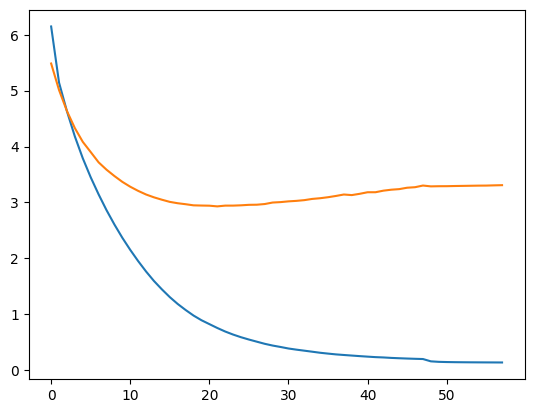

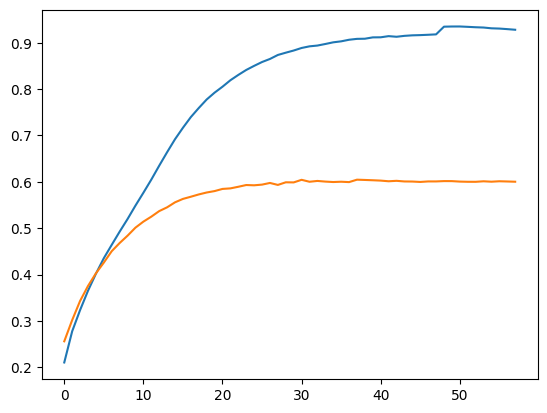

In [7]:
########################################################################################################################
# TRAIN MODEL
########################################################################################################################

train_samples = len(X_train)  # Total Training samples
val_samples = len(X_test)     # Total validation or test samples

model.compile(optimizer=optimizer,
              loss=tf.keras.losses.categorical_crossentropy,
              metrics=[tf.keras.metrics.categorical_accuracy])

# Inicijalizujemo generatore
train_generator = Seq2SeqDataGenerator(X_train, y_train, batch_size, source_word2idx, target_word2idx, max_source_length, max_target_length, num_decoder_tokens)
val_generator = Seq2SeqDataGenerator(X_test, y_test, batch_size, source_word2idx, target_word2idx, max_source_length, max_target_length, num_decoder_tokens)

# callbacks
save_model = tf.keras.callbacks.ModelCheckpoint(model_weights_path, monitor='val_categorical_accuracy', mode='max',
                                                verbose=1, save_best_only=True, save_weights_only=True)

csv_logger = tf.keras.callbacks.CSVLogger(os.path.join(drive_results_folder, 'training.csv'))

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_categorical_accuracy', mode='max',
                                                  patience=20, restore_best_weights=True, verbose=1)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_categorical_accuracy', mode='max',
                                                 factor=0.1, patience=10, verbose=1)

hist = model.fit(x=train_generator,
                 epochs=epochs,
                 validation_data=val_generator,
                 callbacks=[save_model,
                            csv_logger,
                            early_stopping,
                            reduce_lr])

model.save_weights(model_weights_path)

plt.clf()
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.savefig(os.path.join(drive_results_folder, 'training_loss.png'))
plt.show()

plt.clf()
plt.plot(hist.history['categorical_accuracy'])
plt.plot(hist.history['val_categorical_accuracy'])
plt.savefig(os.path.join(drive_results_folder, 'training_accuracy.png'))
plt.show()

In [8]:
########################################################################################################################
# EVALUATE MODEL
########################################################################################################################

model.load_weights(model_weights_path)

# Encode the input sequence to get the "Context vectors"
encoder_model = tf.keras.Model(encoder_inputs, encoder_states)

# Decoder setup
# Below tensors will hold the states of the previous time step
decoder_state_input_h = tf.keras.layers.Input(shape=(latent_dim,))
decoder_state_input_c = tf.keras.layers.Input(shape=(latent_dim,))
decoder_state_input = [decoder_state_input_h, decoder_state_input_c]

# Get the embeddings of the decoder sequence
dec_emb2 = dec_emb_layer(decoder_inputs)

# To predict the next word in the sequence, set the initial states to the states from the previous time step
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=decoder_state_input)
decoder_states2 = [state_h2, state_c2]
# A dense softmax layer to generate prob dist. over the target vocabulary
decoder_outputs2 = decoder_dense(decoder_outputs2)

# Final decoder model
decoder_model = tf.keras.Model([decoder_inputs] + decoder_state_input, [decoder_outputs2] + decoder_states2)


def decode_sequence(input_seq):
    # Encode the input as state vectors
    states_value = encoder_model.predict(input_seq, verbose=0)
    # Generate empty target sequence of length 1
    target_seq = np.zeros((1,1))
    # Populate the first character of target sequence with the start character
    target_seq[0, 0] = target_word2idx['START_']

    # Sampling loop for a batch of sequences (to simplify, here we assume a batch of size 1)
    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = target_idx2word[sampled_token_index]
        decoded_sentence += ' ' + sampled_word

        # Exit condition: either hit max length or find stop character
        if sampled_word == '_END' or len(decoded_sentence) > 50:
            stop_condition = True

        # Update the target sequence (of length 1)
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index

        # Update states
        states_value = [h, c]

    return decoded_sentence


# Data generators
eval_train_gen = Seq2SeqDataGenerator(X_train, y_train, batch_size=1,
                                      source_word2idx=source_word2idx,
                                      target_word2idx=target_word2idx,
                                      max_source_length=max_source_length,
                                      max_target_length=max_target_length,
                                      num_decoder_tokens=num_decoder_tokens)

eval_test_gen = Seq2SeqDataGenerator(X_test, y_test, batch_size=1,
                                     source_word2idx=source_word2idx,
                                     target_word2idx=target_word2idx,
                                     max_source_length=max_source_length,
                                     max_target_length=max_target_length,
                                     num_decoder_tokens=num_decoder_tokens)

# Make predictions on the training dataset
print("================================================================================")
print("Make predictions on the training dataset")
print("================================================================================")
for k in range(10):
    (input_seq, actual_output), _ = eval_train_gen[k]
    decoded_sentence = decode_sequence(input_seq)
    print('Input Source sentence:', X_train[k:k+1].values[0])
    print('Actual Target Translation:', y_train[k:k+1].values[0][6:-4])
    print('Predicted Target Translation:', decoded_sentence[:-4])
    print("--------------------------------------------------------------------------------")

# Make predictions on the test dataset
print()
print("================================================================================")
print("Make predictions on the test dataset")
print("================================================================================")
for k in range(10):
    (input_seq, actual_output), _ = eval_test_gen[k]
    decoded_sentence = decode_sequence(input_seq)
    print('Input Source sentence:', X_test[k:k+1].values[0])
    print('Actual Target Translation:', y_test[k:k+1].values[0][6:-4])
    print('Predicted Target Translation:', decoded_sentence[:-4])
    print("--------------------------------------------------------------------------------")


Make predictions on the training dataset
Input Source sentence: please listen carefully
Actual Target Translation:  molim te slušaj me pažljivo 
Predicted Target Translation:  molim te slušaj me pažljivo 
--------------------------------------------------------------------------------
Input Source sentence: i can do it with my eyes closed
Actual Target Translation:  mogu i žmureći 
Predicted Target Translation:  mogu i žmureći 
--------------------------------------------------------------------------------
Input Source sentence: i wasnt nervous about it
Actual Target Translation:  nisam bila nervozna zbog toga 
Predicted Target Translation:  nisam se unervozio zbog toga 
--------------------------------------------------------------------------------
Input Source sentence: i shaved
Actual Target Translation:  brijala sam se 
Predicted Target Translation:  brijala sam se 
--------------------------------------------------------------------------------
Input Source sentence: everyone sm